In [1]:
from torch import nn
import torch
import numpy as np
from model_training import train, get_data, get_predictions
from cnn import VGGLikeCNN, CNNv2
import matplotlib.pyplot as plt
from contextlib import redirect_stdout

torch.manual_seed(12345)

In [2]:
train_data, val_data, test_data = get_data("standardize", random_crop=True, val_split=0.5)

Random Crop will be used with padding=4
Data standardized with means tensor([0.4914, 0.4822, 0.4465]) and stds tensor([0.2470, 0.2435, 0.2616])

No random crop in test set


/Users/aditkantak/School/courses/cs178/final_project/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")



Training 50 epochs, starting with learning rate 0.01, with AdamW optimizer, with gamma 0.95

Saved training log saved to CNNv2_26-03-13_22-19-01/training_log.txt


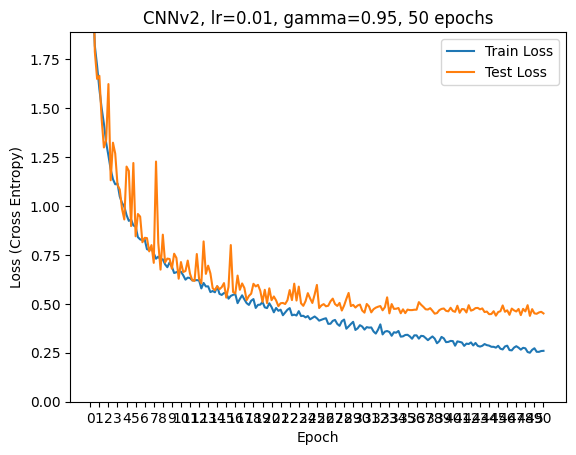

Saved loss graph to CNNv2_26-03-13_22-19-01/loss_curve.png
Saved model weights to CNNv2_26-03-13_22-19-01/weights.pth


In [3]:
BATCH_SIZE = 500
LR = 1e-2
EPOCHS = 50
EVAL_INTERVAL = 25
GAMMA = 0.95
OPTIM = "AdamW"
WEIGHT_DECAY = 9e-2

cnnv2 = CNNv2()
train(cnnv2, train_data, BATCH_SIZE, EPOCHS, LR, val_data=val_data, eval_interval=EVAL_INTERVAL, optim=OPTIM, lr_decay_factor=GAMMA)

In [ ]:
# cnnv2 = CNNv2()
# cnnv2.load_state_dict(torch.load("CNNv2_26-03-13_14-39-43/weights.pth"))

<All keys matched successfully>

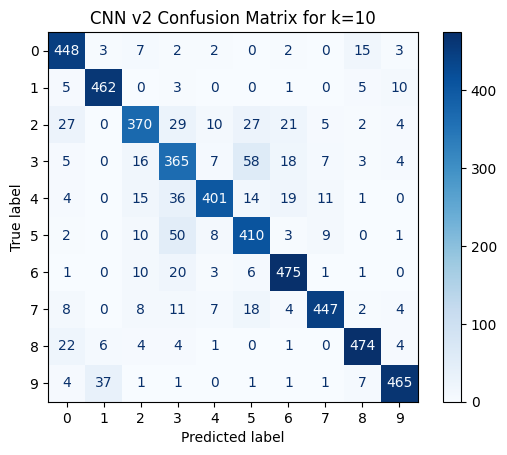

Test set accuracy = 86.34%


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

all_preds, all_targets = get_predictions(cnnv2, test_data, 10)

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap="Blues")
plt.title("CNN v2 Confusion Matrix for k=10")
plt.show()

accuracy = accuracy_score(all_targets, all_preds)
print(f"Test set accuracy = {accuracy:.2%}")

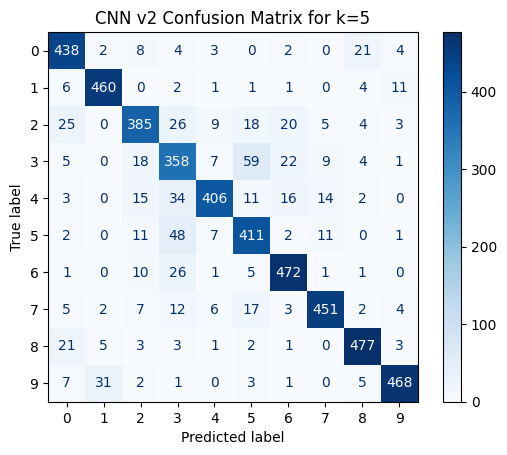

Test set accuracy = 86.52%


In [5]:
all_preds, all_targets = get_predictions(cnnv2, test_data, 5)

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap="Blues")
plt.title("CNN v2 Confusion Matrix for k=5")
plt.show()

accuracy = accuracy_score(all_targets, all_preds)
print(f"Test set accuracy = {accuracy:.2%}")

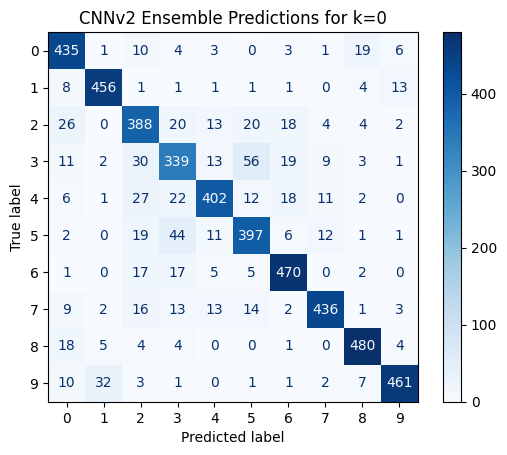

Test set accuracy = 85.28%


In [6]:
all_preds, all_targets = get_predictions(cnnv2, test_data)
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap="Blues")
plt.title("CNNv2 Ensemble Predictions for k=0")
plt.show()

accuracy = accuracy_score(all_targets, all_preds)
print(f"Test set accuracy = {accuracy:.2%}")

In [4]:
# vggparams = sum(torch.numel(x) for x in vgglikecnn.parameters() if x.requires_grad)
cnnv2params = sum(torch.numel(x) for x in cnnv2.parameters() if x.requires_grad)

print(f"{'Model Type':<15} {'Params':<10}")
print("-"*50)
# print(f"{'VGGLikeCNN':<15} {vggparams:<10}")
print(f"{'CNNv2':<15} {cnnv2params:<10}")

Model Type      Params    
--------------------------------------------------
CNNv2           295770    
